In [1]:
import torch
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(context="notebook",style="whitegrid",palette="dark")

In [2]:
data=pd.read_csv("ex1data1.txt",names=["population","profit"])

In [3]:
data.head()

,population,profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   population  97 non-null     float64
 1   profit      97 non-null     float64
dtypes: float64(2)
memory usage: 1.6 KB


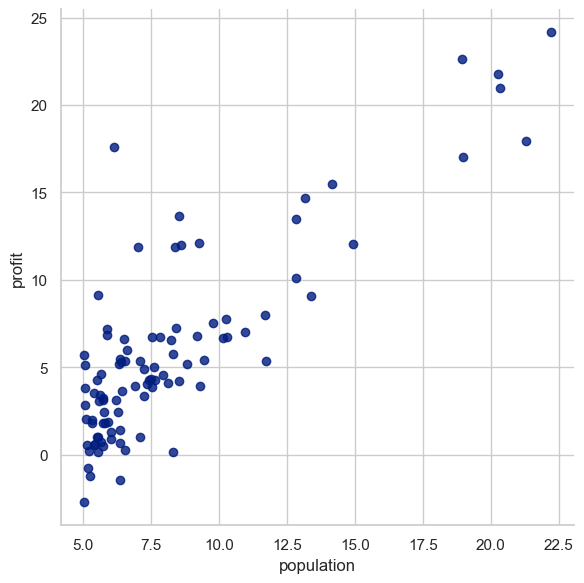

In [5]:
sns.lmplot(x="population",y="profit",data=data,height=6,fit_reg=False)
plt.show()

In [6]:
def get_x(data):
    ones=pd.DataFrame({"ones":np.ones(len(data))})
    data=pd.concat([ones,data],axis=1)
    return data.iloc[:,:-1].values

X=get_x(data)
print(X)

[[ 1.      6.1101]
 [ 1.      5.5277]
 [ 1.      8.5186]
 [ 1.      7.0032]
 [ 1.      5.8598]
 [ 1.      8.3829]
 [ 1.      7.4764]
 [ 1.      8.5781]
 [ 1.      6.4862]
 [ 1.      5.0546]
 [ 1.      5.7107]
 [ 1.     14.164 ]
 [ 1.      5.734 ]
 [ 1.      8.4084]
 [ 1.      5.6407]
 [ 1.      5.3794]
 [ 1.      6.3654]
 [ 1.      5.1301]
 [ 1.      6.4296]
 [ 1.      7.0708]
 [ 1.      6.1891]
 [ 1.     20.27  ]
 [ 1.      5.4901]
 [ 1.      6.3261]
 [ 1.      5.5649]
 [ 1.     18.945 ]
 [ 1.     12.828 ]
 [ 1.     10.957 ]
 [ 1.     13.176 ]
 [ 1.     22.203 ]
 [ 1.      5.2524]
 [ 1.      6.5894]
 [ 1.      9.2482]
 [ 1.      5.8918]
 [ 1.      8.2111]
 [ 1.      7.9334]
 [ 1.      8.0959]
 [ 1.      5.6063]
 [ 1.     12.836 ]
 [ 1.      6.3534]
 [ 1.      5.4069]
 [ 1.      6.8825]
 [ 1.     11.708 ]
 [ 1.      5.7737]
 [ 1.      7.8247]
 [ 1.      7.0931]
 [ 1.      5.0702]
 [ 1.      5.8014]
 [ 1.     11.7   ]
 [ 1.      5.5416]
 [ 1.      7.5402]
 [ 1.      5.3077]
 [ 1.      7

In [7]:
def get_y(data):
    return data.iloc[:,-1:].values
Y=get_y(data)
print(Y)

[[17.592  ]
 [ 9.1302 ]
 [13.662  ]
 [11.854  ]
 [ 6.8233 ]
 [11.886  ]
 [ 4.3483 ]
 [12.     ]
 [ 6.5987 ]
 [ 3.8166 ]
 [ 3.2522 ]
 [15.505  ]
 [ 3.1551 ]
 [ 7.2258 ]
 [ 0.71618]
 [ 3.5129 ]
 [ 5.3048 ]
 [ 0.56077]
 [ 3.6518 ]
 [ 5.3893 ]
 [ 3.1386 ]
 [21.767  ]
 [ 4.263  ]
 [ 5.1875 ]
 [ 3.0825 ]
 [22.638  ]
 [13.501  ]
 [ 7.0467 ]
 [14.692  ]
 [24.147  ]
 [-1.22   ]
 [ 5.9966 ]
 [12.134  ]
 [ 1.8495 ]
 [ 6.5426 ]
 [ 4.5623 ]
 [ 4.1164 ]
 [ 3.3928 ]
 [10.117  ]
 [ 5.4974 ]
 [ 0.55657]
 [ 3.9115 ]
 [ 5.3854 ]
 [ 2.4406 ]
 [ 6.7318 ]
 [ 1.0463 ]
 [ 5.1337 ]
 [ 1.844  ]
 [ 8.0043 ]
 [ 1.0179 ]
 [ 6.7504 ]
 [ 1.8396 ]
 [ 4.2885 ]
 [ 4.9981 ]
 [ 1.4233 ]
 [-1.4211 ]
 [ 2.4756 ]
 [ 4.6042 ]
 [ 3.9624 ]
 [ 5.4141 ]
 [ 5.1694 ]
 [-0.74279]
 [17.929  ]
 [12.054  ]
 [17.054  ]
 [ 4.8852 ]
 [ 5.7442 ]
 [ 7.7754 ]
 [ 1.0173 ]
 [20.992  ]
 [ 6.6799 ]
 [ 4.0259 ]
 [ 1.2784 ]
 [ 3.3411 ]
 [-2.6807 ]
 [ 0.29678]
 [ 3.8845 ]
 [ 5.7014 ]
 [ 6.7526 ]
 [ 2.0576 ]
 [ 0.47953]
 [ 0.20421]
 [ 0.67861]
 [ 7

In [8]:
X_tensor=torch.from_numpy(X).float()
Y_tensor=torch.from_numpy(Y).float()

In [11]:
# 初始化为全 0 的 2行1列 矩阵
# requires_grad=True：告诉 PyTorch，“请帮我盯着这两个数，以后我要算它们的导数”
theta=torch.zeros((2,1),requires_grad=True)

print("初始参数 theta:")
print(theta)

初始参数 theta:
tensor([[0.],
        [0.]], requires_grad=True)


In [12]:
alpha=0.01
epochs=1500
m=len(X_tensor)

In [13]:
cost=[]
for i in range(epochs):
    y_hat=X_tensor@theta
    loss=torch.sum((y_hat-Y_tensor)**2)/(2*m)
    cost.append(loss.item())
    loss.backward()

    with torch.no_grad():
        theta-=alpha*theta.grad
        theta.grad.zero_()

    if i % 100 == 0:
        print(f"Epoch {i}: Cost = {loss.item():.4f}")

print("\n训练完成！")
print(f"最终的 theta 为:\n{theta.detach().numpy()}")

Epoch 0: Cost = 32.0727
Epoch 100: Cost = 5.4800
Epoch 200: Cost = 5.1762
Epoch 300: Cost = 4.9644
Epoch 400: Cost = 4.8167
Epoch 500: Cost = 4.7138
Epoch 600: Cost = 4.6421
Epoch 700: Cost = 4.5921
Epoch 800: Cost = 4.5572
Epoch 900: Cost = 4.5329
Epoch 1000: Cost = 4.5160
Epoch 1100: Cost = 4.5041
Epoch 1200: Cost = 4.4959
Epoch 1300: Cost = 4.4902
Epoch 1400: Cost = 4.4862

训练完成！
最终的 theta 为:
[[-3.6302927]
 [ 1.1663625]]


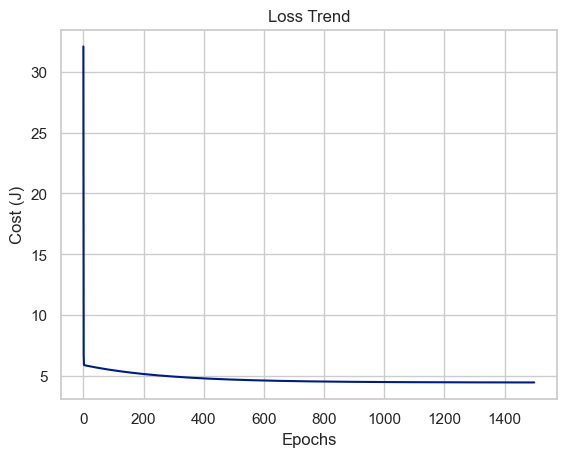

In [14]:
plt.plot(range(len(cost)), cost)
plt.xlabel('Epochs')
plt.ylabel('Cost (J)')
plt.title('Loss Trend')
plt.show()

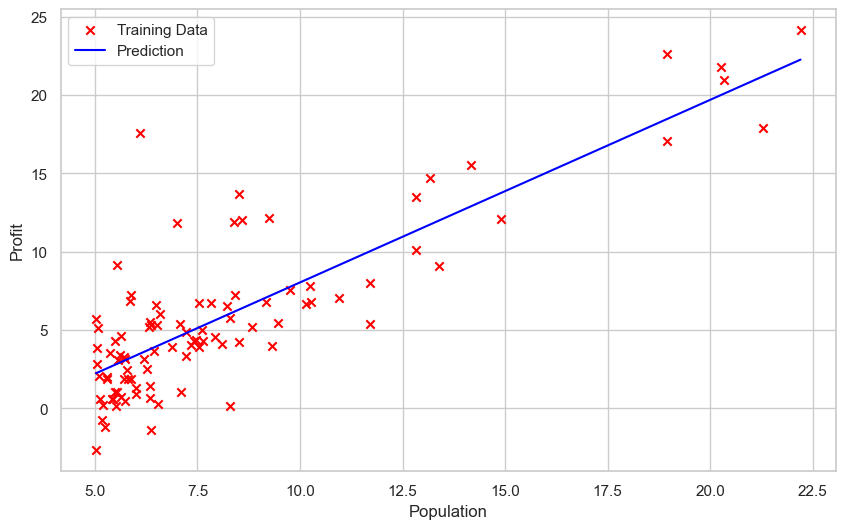

In [15]:
theta_final=theta.detach().numpy()

x_axis = np.linspace(data.population.min(), data.population.max(), 100)
f = theta_final[0, 0] + (theta_final[1, 0] * x_axis)

plt.figure(figsize=(10, 6))
plt.scatter(data.population, data.profit, label='Training Data', color='red', marker='x')
plt.plot(x_axis, f, label='Prediction', color='blue')
plt.xlabel('Population')
plt.ylabel('Profit')
plt.legend()
plt.show()